<a href="https://colab.research.google.com/github/mzaib1012/AI-Data-Center-Microgrid-with-Battery-Storage-Peak-Shaving-Controller/blob/main/notebooks/peak_shaving_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a time array representing 24 hours, sampled every 5 minutes
# 5 minutes is 5/60 of an hour. This gives us 288 data points across the day.
time = np.arange(0, 24, 5/60)

# 2. Establish the baseline power consumption (Cooling + Basic Server Idle)
# Let's assume this baseline is a steady 15 Megawatts (MW)
base_load = 15.0

# Add some minor random noise to make it look like a real fluctuating grid
np.random.seed(42) # Ensures the random noise looks the same every time you run it
noise = np.random.normal(0, 0.5, len(time))

# 3. Simulate two major AI training spikes
# A medium model training run peaking around 09:00 AM (adds up to 12 MW)
training_spike_1 = 12 * np.exp(-((time - 9)**2) / 1.5)
# A massive LLM model training run peaking around 05:00 PM (adds up to 18 MW)
training_spike_2 = 18 * np.exp(-((time - 17)**2) / 2.0)

# Combine them all together to get the total load profile
datacenter_demand = base_load + training_spike_1 + training_spike_2 + noise

# Store this data into a structured table (DataFrame) so it's easy to read
df = pd.DataFrame({'Time_Hours': time, 'Demand_MW': datacenter_demand})

print("Step 1 Complete: AI Data Center load profile successfully created!")

Step 1 Complete: AI Data Center load profile successfully created!


In [5]:
# --- BESS (Battery Energy Storage System) & Grid Parameters ---
BESS_CAPACITY_MWh = 20.0  # Total energy storage capacity
INITIAL_SOC = 0.5         # Start the day half-full (50%)
MIN_SOC = 0.2             # Protection limit: never drop below 20%
MAX_SOC = 1.0             # Protection limit: never exceed 100%
MAX_POWER_MW = 8.0        # Max physical power line capacity of the BESS
CHARGE_EFFICIENCY = 0.95  # 95% efficiency during charging
DISCHARGE_EFFICIENCY = 0.95 # 95% efficiency during discharging

PEAK_THRESHOLD_MW = 20.0   # Substation safety limit cap
CHARGE_TARGET_MW = 16.0    # Lower bound threshold to allow charging
CHARGE_RATE_MW = 3.0       # Charging speed from grid during low demand

# --- Arrays to Store Simulation Results ---
grid_power = []
bess_power = []            # Positive = Discharging (Helping), Negative = Charging
soc_history = [INITIAL_SOC]
dt = 5 / 60                # Time step: 5 minutes converted into hours unit

current_soc = INITIAL_SOC

# --- Step-by-Step Time Series Simulation ---
for demand in df['Demand_MW']:
    p_bess = 0.0

    # CONDITION 1: Peak Shaving Mode (Demand exceeds safe threshold)
    if demand > PEAK_THRESHOLD_MW:
        needed_power = demand - PEAK_THRESHOLD_MW

        # Calculate how much energy is physically available to discharge safely
        available_energy = (current_soc - MIN_SOC) * BESS_CAPACITY_MWh * DISCHARGE_EFFICIENCY
        max_possible_discharge = min(MAX_POWER_MW, available_energy / dt)

        # Dispatch the minimum between what we need vs what the battery can physically provide
        p_bess = min(needed_power, max_possible_discharge)
        p_grid = demand - p_bess

        # Update State of Charge (Discharging reduces battery energy status)
        current_soc -= (p_bess / DISCHARGE_EFFICIENCY) * dt / BESS_CAPACITY_MWh

    # CONDITION 2: Charging Mode (Low grid usage & battery has space)
    elif demand < CHARGE_TARGET_MW and current_soc < MAX_SOC:
        # Calculate how much space is left in the battery to store energy
        available_room = (MAX_SOC - current_soc) * BESS_CAPACITY_MWh / CHARGE_EFFICIENCY
        max_possible_charge = min(MAX_POWER_MW, available_room / dt)

        # Set charging power (expressed as negative power in standard grid convention)
        p_bess = -min(CHARGE_RATE_MW, max_possible_charge)
        p_grid = demand - p_bess # Grid power increases slightly to supply charging loop

        # Update State of Charge (Charging increases battery energy status)
        current_soc -= (p_bess * CHARGE_EFFICIENCY) * dt / BESS_CAPACITY_MWh

    # CONDITION 3: Normal Safe Mode (Do nothing, pass through)
    else:
        p_grid = demand
        p_bess = 0.0
        current_soc = current_soc

    # Append calculated values to results list
    grid_power.append(p_grid)
    bess_power.append(p_bess)
    soc_history.append(current_soc)

# Clean up trailing array index element to match dataframe row dimensions
soc_history.pop()

# Inject results directly back into our structured data table
df['Grid_Power_MW'] = grid_power
df['BESS_Power_MW'] = bess_power
df['SOC'] = soc_history

print("Step 2 Complete: Controller algorithm simulation successfully completed!")

Step 2 Complete: Controller algorithm simulation successfully completed!


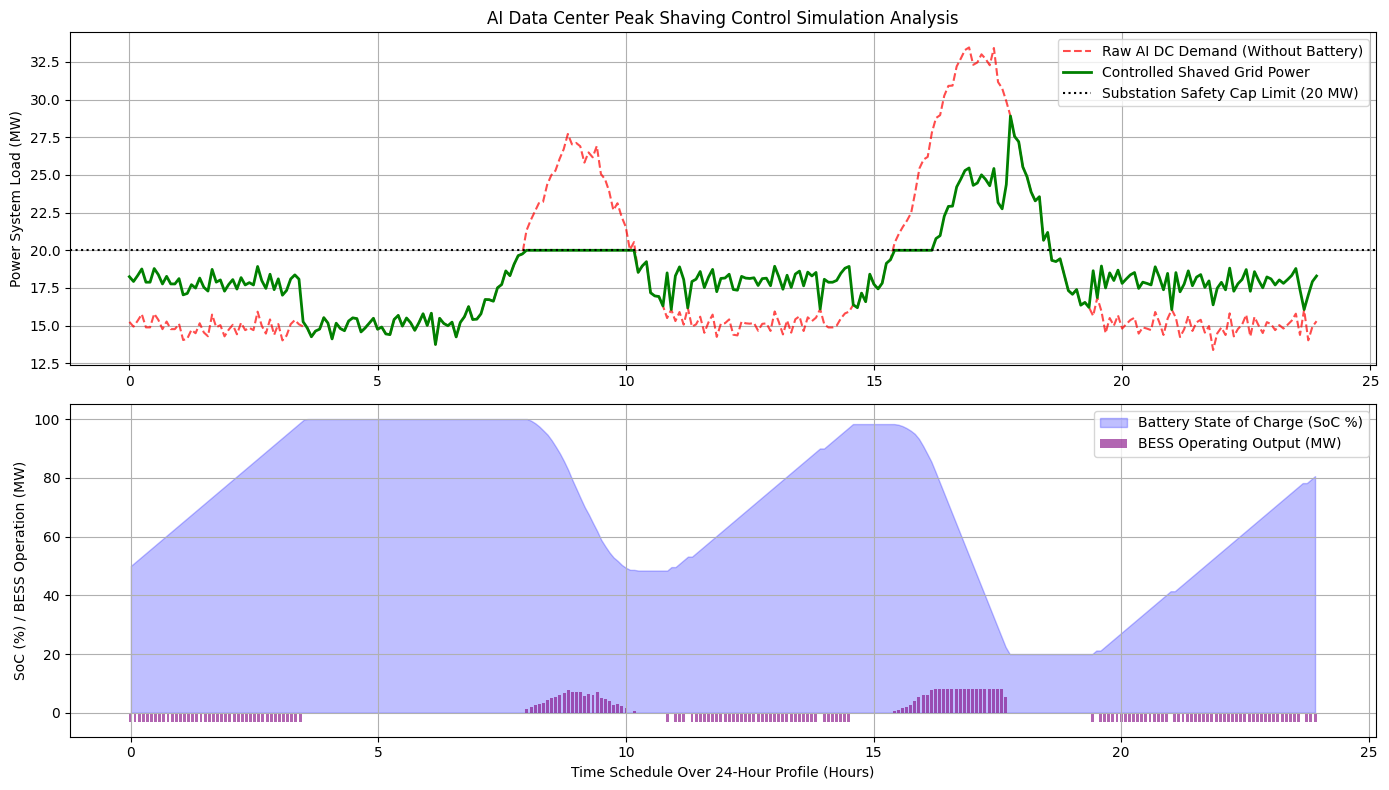

In [6]:
plt.figure(figsize=(14, 8))

# Subplot 1: Power Profiles vs Time
plt.subplot(2, 1, 1)
plt.plot(df['Time_Hours'], df['Demand_MW'], label='Raw AI DC Demand (Without Battery)', color='red', linestyle='--', alpha=0.7)
plt.plot(df['Time_Hours'], df['Grid_Power_MW'], label='Controlled Shaved Grid Power', color='green', linewidth=2)
plt.axhline(y=PEAK_THRESHOLD_MW, color='black', linestyle=':', label='Substation Safety Cap Limit (20 MW)')
plt.title('AI Data Center Peak Shaving Control Simulation Analysis')
plt.ylabel('Power System Load (MW)')
plt.legend(loc='upper right')
plt.grid(True)

# Subplot 2: Battery Energy Status (SOC) & Action Profile
plt.subplot(2, 1, 2)
plt.fill_between(df['Time_Hours'], df['SOC'] * 100, color='blue', alpha=0.25, label='Battery State of Charge (SoC %)')
plt.bar(df['Time_Hours'], df['BESS_Power_MW'], width=0.06, color='purple', alpha=0.6, label='BESS Operating Output (MW)')
plt.xlabel('Time Schedule Over 24-Hour Profile (Hours)')
plt.ylabel('SoC (%) / BESS Operation (MW)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
# This saves the chart as an image file inside Google's cloud storage
plt.savefig('simulation_results.png', dpi=300)
plt.show()